In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [1]:
# 基础库
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch 相关库
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.nn.init as init
from torch.utils.tensorboard import SummaryWriter
import torchvision
import torchvision.transforms as transforms

# 图像处理相关库
from PIL import Image, ImageOps, ImageFilter
import cv2
from skimage import transform
from scipy.ndimage import label, center_of_mass
from scipy.optimize import curve_fit
from skimage import data
from skimage.transform import resize

# Matplotlib 颜色模块
import matplotlib.colors as mcolors

导入网络结构

In [2]:
#from __future__ import division
#from math import sqrt

class DoubleConV(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super(DoubleConV, self).__init__()
        self.pad = nn.ReplicationPad2d(1)
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, padding_mode='replicate', bias=False),
            #这里设置了bias = false, 应该相当于后面对bias取成全零矩阵，有待验证？
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, padding_mode='replicate', bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, X):
        return self.double_conv(X)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Down, self).__init__()
        self.maxpool = nn.Sequential(
            nn.MaxPool2d(2),
            #注：此处stride=None,但是Xin等设置了stride=2
            DoubleConV(in_channels, out_channels)
        )

    def forward(self, X):
        return self.maxpool(X)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super(Up, self).__init__()
        if bilinear:
            #self.up = nn.Upsample(scale_factor=2, model='bilnear', align_corners='True'),
            #bilinear双线性插值
            self.up = nn.UpsamplingBilinear2d(scale_factor=2)
            # scale_factor输出对输入的倍数，主要改变图片高宽，bilinear双线性插值
            self.conv = DoubleConV(in_channels, out_channels, in_channels//2)
            #self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1)
            #self.bn = nn.BatchNorm2d(out_channels)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            #没有加padding，待验证？
            self.conv = DoubleConV(in_channels, out_channels)
            #转置卷积，另外一种上采样的方式，不过一般都用双线性插值方法

    def forward(self, X1, X2):
        X1 = self.up(X1)
        #X1 = self.conv1(X1)
        #X1 = self.bn(X1)
        #将X1通道数减半
        #print(X2.size(),X1.size())
        if not (X2.size()[2] == X1.size()[2] or X2.size()[3] == X1.size()[3]):
            DetaX = X1.size()[2] - X2.size()[2]
            DetaY = X1.size()[3] - X2.size()[3]
            X2 = F.pad(X2, [DetaX // 2, DetaX - DetaX // 2,
                            DetaY // 2, DetaY - DetaY // 2], mode='replicate')
            #如果X1和X2大小不一样，将X2进行填充，到和X1相同的大小
            print('there is different cat_size, and we let X2 the same as X1 atomatically')
            #输出提示
        X = torch.cat([X2, X1], dim=1)
        #对每个通道的X1,X2整合到一起
        return self.conv(X)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, X):
        return self.conv(X)

In [3]:
class Unet(nn.Module):
    def __init__(self, colordim=1, n_classes=2, drop=0.5, bilinear=True):
        super(Unet, self).__init__()
        self.colordim = colordim
        self.n_classes = n_classes

        self.inp = DoubleConV(colordim, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512,1024//factor)
        self.up1 = Up(1024, 512//factor, bilinear)
        self.up2 = Up(512, 256//factor, bilinear)
        self.up3 = Up(256, 128//factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outp = OutConv(64, n_classes)
        #self.dropout = nn.Dropout(drop)

    def forward(self, X, drop=0.5):
        X1 = self.inp(X)
        X2 = self.down1(X1)
        X3 = self.down2(X2)
        X4 = self.down3(X3)
        #X4_1 = self.dropout(X4)
        X5 = self.down4(X4)
        #X5 = self.dropout(X5)
        X = self.up1(X5, X4)
        X = self.up2(X, X3)
        X = self.up3(X, X2)
        X = self.up4(X, X1)
        out = self.outp(X)
        return out

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_normal_(m.weight.data)
                nn.init.constant_(m.bias.data, 0.0)
            if isinstance(m, nn.BatchNorm2d):
                nn.init.xavier_normal_(m.weight.data)
                nn.init.constant_(m.bias.data, 0.0)

原子识别--图片预处理

In [4]:
def pad_img(image, target_size):
    """将图像填充或缩放为目标尺寸 (256, 256)。"""
    iw, ih = image.size  # 原始图像的宽高
    tw, th = target_size  # 目标尺寸 (256, 256)

    # 计算缩放比例，保持高宽比
    scale = min(tw / iw, th / ih)
    nw, nh = int(iw * scale), int(ih * scale)

    # 缩放图像
    image = image.resize((nw, nh), Image.BILINEAR)

    # 创建新的背景图像，并将缩放后的图像粘贴到中心
    new_image = Image.new("L", target_size)
    new_image.paste(image, ((tw - nw) // 2, (th - nh) // 2))

    return new_image, nw, nh

def pred(image, height_periodicity):
    """
    根据高度方向的周期将图像切割为正方形，并进行预测。
    """
    old_image = image  # 备份原始图像

    # 初始化 transform
    transform1 = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor()
    ])
    transform2 = transforms.ToPILImage()

    # 计算高度方向的块大小
    box_height = image.height // height_periodicity
    box_size = box_height  # 每块是正方形，大小为 box_size x box_size

    # 按比例计算输出的宽度（未取整）
    proportional_width = (image.width * height_periodicity * 256) / image.height

    # 向上取整宽度周期数，保证块对齐
    width_periodicity = int(np.ceil(proportional_width / 256))
    output_width = width_periodicity * 256  # 取整后的输出宽度
    output_height = height_periodicity * 256  # 输出高度

    # 初始化输出图像（含多余部分）
    output = Image.new('L', (output_width, output_height))

    # 遍历高度和宽度方向的图像块
    for i in range(width_periodicity):
        for j in range(height_periodicity):
            # 计算当前块的坐标
            left = i * box_size
            upper = j * box_height
            right = min((i + 1) * box_size, image.width)
            lower = (j + 1) * box_height

            # 裁剪图像块
            image_ij = image.crop((left, upper, right, lower))

            # 如果块宽度不够 box_size，则在右侧填充
            if image_ij.width < box_size:
                pad_width = box_size - image_ij.width
                image_ij = ImageOps.expand(image_ij, (0, 0, pad_width, 0), fill=0)

            # 填充或缩放为 (256, 256)
            image_ij, nw, nh = pad_img(image_ij, (256, 256))

            # 转换为 Tensor 并调整形状
            image_ij = transform1(image_ij)
            image_ij = torch.reshape(image_ij, (1, 1, 256, 256))

            # 加载 U-Net 模型并进行预测
            model = Unet()
            model.load_state_dict(torch.load('model.pth')['model_state_dict'])
            model.eval()

            with torch.no_grad():
                output_ij = model(image_ij)

            # 获取预测结果并归一化
            output_ij = torch.argmax(output_ij, dim=1)
            output_ij = torch.reshape(output_ij, (256, 256)).float()
            output_ij /= output_ij.max()  # 归一化为 [0, 1]
            output_ij = transform2(output_ij)  # 转回 PIL 图像

            # 裁剪掉多余的填充部分
            crop_box = (
                (256 - nw) // 2, (256 - nh) // 2,
                256 - (256 - nw) // 2, 256 - (256 - nh) // 2
            )
            output_ij = output_ij.crop(crop_box)

            # 计算拼接位置并粘贴预测结果
            paste_x = 256 * i
            paste_y = 256 * j
            output.paste(output_ij, (paste_x, paste_y))

    # 按比例裁剪掉多余的部分，使输出宽高比正确
    final_width = int(proportional_width)  # 按比例计算的最终宽度
    output = output.crop((0, 0, final_width, output_height))

    return old_image, output

In [5]:
def visualize_images(original, predicted):
    """使用 Matplotlib 可视化原始图像和预测结果。"""
    plt.figure(figsize=(12, 6))

    # 显示原始图像
    plt.subplot(1, 2, 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    # 显示预测结果
    plt.subplot(1, 2, 2)
    plt.imshow(predicted, cmap='gray')
    plt.title("Predicted Image")
    plt.axis('off')

    # 展示图片
    plt.show()

In [6]:
def resize_image_to_match(image, target_image):
    """将 output_image 的尺寸调整为与 image 一致。"""
    return image.resize(target_image.size, Image.NEAREST)

def erode_and_dilate(image, kernel_size=3, iterations=1):
    """对图像进行腐蚀和膨胀，去除噪声点。"""
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    np_image = np.array(image)
    eroded = cv2.erode(np_image, kernel, iterations=iterations)
    cleaned = cv2.dilate(eroded, kernel, iterations=iterations)
    return Image.fromarray(cleaned)

def gaussian_2d(xy, A, x0, y0, sigma_x, sigma_y, B):
    """2D 高斯函数，包含背景常数 B。"""
    x, y = xy
    return A * np.exp(-(((x - x0) ** 2) / (2 * sigma_x ** 2) + ((y - y0) ** 2) / (2 * sigma_y ** 2))) + B

def find_centroids(image):
    """寻找图像中所有连通区域的质心。"""
    labeled, num_features = label(np.array(image))
    centroids = center_of_mass(np.array(image), labeled, range(1, num_features + 1))
    return centroids

def crop_region(image, center, size=50):
    """根据给定中心坐标裁剪出一个区域。"""
    x, y = int(center[1]), int(center[0])
    half_size = size // 2
    return image.crop((x - half_size, y - half_size, x + half_size + 1, y + half_size + 1))

def fit_gaussian_to_atom(cropped_image):
    """对裁剪的区域进行高斯拟合，返回拟合后的中心位置和峰高。"""
    cropped_np = np.array(cropped_image)
    y, x = np.indices(cropped_np.shape)

    initial_guess = (
        np.max(cropped_np) - np.min(cropped_np),  # A: 峰值
        cropped_np.shape[1] / 2,  # x0: 初始x位置
        cropped_np.shape[0] / 2,  # y0: 初始y位置
        2.0, 2.0,  # sigma_x, sigma_y
        np.min(cropped_np)  # B: 背景常数
    )

    try:
        popt, _ = curve_fit(
            gaussian_2d,
            (x.ravel(), y.ravel()),
            cropped_np.ravel(),
            p0=initial_guess
        )
        A, x0, y0, sigma_x, sigma_y, B = popt
        return (x0, y0), A  # 返回拟合的中心位置和峰高
    except RuntimeError:
        return None, None

def visualize_cropped_region(cropped, center, title="Cropped Region with Fitted Center"):
    """可视化裁剪区域及其拟合的中心位置。"""
    plt.figure(figsize=(5, 5))
    plt.imshow(cropped, cmap='gray')
    plt.scatter(center[0], center[1], color='red', marker='x', s=50)
    plt.title(title)
    plt.axis('off')
    plt.show()

def process_images(image, output_image, blur_kernel=(9, 9), crop_size=15):
    """在 output_image 上寻找中心位置，并在 image 上进行高斯拟合。"""
    # 调整 output_image 的尺寸与 image 一致
    output_image = resize_image_to_match(output_image, image)

    blurred = cv2.GaussianBlur(np.array(image), blur_kernel, 0)
    image = Image.fromarray(blurred)

    # 对 output_image 进行腐蚀和膨胀处理
    processed_image = erode_and_dilate(output_image)

    # 在处理后的图像上寻找连通区域的质心
    centroids = find_centroids(processed_image)

    atom_positions = []  # 存储原子位置和峰高

    # 在原图上裁剪区域并进行高斯拟合
    for idx, centroid in enumerate(centroids):
        # 裁剪原图中的局部区域
        cropped = crop_region(image, centroid, size=crop_size)

        # 对局部区域进行高斯拟合
        center, peak = fit_gaussian_to_atom(cropped)

        if center is not None:
            if idx%50==0:
                # 可视化裁剪区域及其拟合的中心
                visualize_cropped_region(cropped, center, title=f"Region {idx + 1}")

            # 计算全局坐标，确保不超出图像范围
            global_x = int(centroid[1] - (cropped.size[0] / 2) + center[0])
            global_y = int(centroid[0] - (cropped.size[1] / 2) + center[1])

            # 检查全局坐标是否在图像范围内
            if 0 <= global_x < image.size[0] and 0 <= global_y < image.size[1]:
                if 0 < peak < 255:
                    atom_positions.append(((global_x, global_y), peak))

    return atom_positions


def visualize_results(image, atom_positions):
    """在原图上标注原子位置，并显示峰高分布。"""
    plt.figure(figsize=(12, 6))

    # 在左侧展示标注原子位置的原始图像
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Detected Atoms")

    # 用红色 X 标记每个原子的中心位置
    peaks = []
    for (x, y), peak in atom_positions:
        plt.plot(x, y, 'rx', markersize=8)
        peaks.append(peak)

    # 在右侧展示峰高分布
    plt.subplot(1, 2, 2)
    plt.hist(peaks, bins=20, color='blue', alpha=0.7)
    plt.title("Peak Intensity Distribution")
    plt.xlabel("Peak Height")
    plt.ylabel("Frequency")

    plt.show()

In [7]:
def filter_atoms_by_peak(atom_positions, min_peak=80, max_peak=160):
    """筛选峰高在指定范围内的原子。"""
    return [
        (position, peak) for position, peak in atom_positions
        if min_peak <= peak <= max_peak
    ]

def calculate_nearest_neighbor_distances(atom_positions):
    """计算每个原子的最近邻距离，并返回这些距离的平均值。"""
    distances = []
    n = len(atom_positions)
    for i in range(n):
        min_dist = float('inf')
        for j in range(n):
            if i != j:
                dist = np.linalg.norm(np.array(atom_positions[i][0]) - np.array(atom_positions[j][0]))
                if dist < min_dist:
                    min_dist = dist
        distances.append(min_dist)
    return np.mean(distances) if distances else 0

def remove_close_atoms(atom_positions, avg_nn_distance):
    """
    删除距离小于平均最近邻距离的一半（avg_nn_distance / 1.2）的原子，按峰值从小到大遍历，
    保留峰高较大的原子。
    """
    # 按峰值从小到大排序
    sorted_atoms = sorted(atom_positions, key=lambda x: x[1])
    
    # 存储要保留的原子
    kept_atoms = []

    while sorted_atoms:
        # 每次取出峰值最低的原子作为当前原子
        current_atom = sorted_atoms.pop(0)
        keep = True

        # 检查是否与已保留的任何原子距离过近
        for kept_atom in kept_atoms:
            dist = np.linalg.norm(np.array(current_atom[0]) - np.array(kept_atom[0]))
            if dist < avg_nn_distance:
                keep = False  # 当前原子与已保留的原子过近，舍弃
                break

        if keep:
            kept_atoms.append(current_atom)  # 仅保留未被舍弃的原子

    return kept_atoms

def mark_atoms_on_image(image, atom_positions,avg_nn_distance):
    """在图像上标注原子位置。"""
    plt.figure(figsize=(8, 8))
    plt.imshow(image, cmap='gray')
    for (x, y), peak in atom_positions:
        plt.plot(x, y, 'rx', markersize=8)
        plt.text(x + 2, y + 2, f'{peak:.1f}', color='yellow', fontsize=8)
    # 为原子位置画圆，半径为 avg_nn_distance
    circle = plt.Circle((x, y), radius = avg_nn_distance, color='cyan', fill=False, linewidth=1.5)
    plt.gca().add_patch(circle)
    
    plt.title("Filtered Atoms with Peak Values")
    plt.axis('off')
    plt.show()

In [31]:
def calculate_angle_with_axis(O, P, axis='x'):
    """
    计算向量 OP 与指定轴（x 或 y）之间的夹角。
    axis='x'：计算与水平轴的夹角。
    axis='y'：计算与垂直轴的夹角。
    """
    vector = np.array(P) - np.array(O)
    
    # 根据指定的轴创建参考向量
    if axis == 'x':
        reference_vector = np.array([1, 0])  # 水平轴
    elif axis == '-x':
        reference_vector = np.array([-1, 0])  # 水平轴
    elif axis == '-y':
        reference_vector = np.array([0, -1])  # 垂直轴
    elif axis == 'y':
        reference_vector = np.array([0, 1])  # 垂直轴
    else:
        raise ValueError("Axis must be 'x' or 'y'.")
    
    # 使用余弦定理计算夹角
    cos_angle = np.dot(vector, reference_vector) / (np.linalg.norm(vector) * np.linalg.norm(reference_vector))
    angle = np.degrees(np.arccos(np.clip(cos_angle, -1.0, 1.0)))  # 防止浮点误差导致的错误
    return angle

def calculate_angle_between_vectors(A, B, O):
    """
    计算向量 OA 和 OB 之间的夹角。
    A, B, O 分别为三个点的坐标，O 是公共点。
    """
    vector_OA = np.array(A) - np.array(O)
    vector_OB = np.array(B) - np.array(O)

    # 计算余弦值并防止浮点数误差超出 [-1, 1] 范围
    cos_theta = np.dot(vector_OA, vector_OB) / (
        np.linalg.norm(vector_OA) * np.linalg.norm(vector_OB)
    )
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    # 返回夹角的度数
    angle = np.degrees(np.arccos(cos_theta))
    return angle

def find_nearest_atoms(O, final_atoms, avg_nn_distance):
    """寻找与 x 轴和 y 轴接近的最近邻原子 A、B、C。"""
    # 筛选出在指定范围内的候选原子
    candidates = [
        pos for pos, _ in final_atoms
        if np.linalg.norm(np.array(O) - np.array(pos)) <= avg_nn_distance and not np.allclose(pos, O)
    ]

    # 找到与y方向接近的原子 A
    y_candidates = [
        pos for pos in candidates
        if -20<= calculate_angle_with_axis(O, pos, axis='-y') <= 20  # 限制在 20 度以内
    ]
    A = min(y_candidates, key=lambda pos: np.linalg.norm(np.array(O) - np.array(pos)), default=None)

    # 找到与垂直轴（y方向）接近的原子 B 和 C
    x_candidates = [
        pos for pos in candidates
        if -10 <= calculate_angle_with_axis(O, pos, axis='x') <= 10 # 限制在 10 度以内
    ]
    B = min(x_candidates, key=lambda pos: np.linalg.norm(np.array(O) - np.array(pos)), default=None)

    _x_candidates = [
        pos for pos in candidates
        if -10 <= calculate_angle_with_axis(O, pos, axis='-x') <= 10 # 限制在 10 度以内
    ]
    C = min(_x_candidates, key=lambda pos: np.linalg.norm(np.array(O) - np.array(pos)), default=None)

    return A, B, C

def visualize_single_atom_with_vectors(image, O, A, B, C, radius):
    """可视化原子 O，并展示 OA、OB 和 OC 向量及其邻近关系，同时标出 x 和 y 轴。"""
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image, cmap='gray')


    ox, oy = O
    circle = plt.Circle((ox, oy), radius=radius, color='cyan', fill=False, linewidth=1.5)
    ax.add_patch(circle)
    ax.plot(ox, oy, 'ro', markersize=10, label='O (Selected)')

    # 绘制 x 和 y 轴的虚线
    ax.axhline(oy, color='blue', linestyle='--', linewidth=1, label='x-axis')
    ax.axvline(ox, color='green', linestyle='--', linewidth=1, label='y-axis')

    # 绘制 OA 向量（水平方向）
    if A:
        ax.plot(A[0], A[1], 'bo', markersize=8, label='A (x-direction)')
        ax.arrow(ox, oy, A[0] - ox, A[1] - oy, color='blue', head_width=5, length_includes_head=True)

    # 绘制 OB 和 OC 向量（垂直方向）
    if B:
        ax.plot(B[0], B[1], 'go', markersize=8, label='B (y-direction)')
        ax.arrow(ox, oy, B[0] - ox, B[1] - oy, color='green', head_width=5, length_includes_head=True)

    if C:
        ax.plot(C[0], C[1], 'mo', markersize=8, label='C (y-direction)')
        ax.arrow(ox, oy, C[0] - ox, C[1] - oy, color='magenta', head_width=5, length_includes_head=True)

    ax.legend(loc='upper right')
    plt.title("Visualization of Atom O with Nearest Neighbors and Axes")
    plt.axis('off')
    plt.show()

def mark_features_on_image(image, features, plt_text=1, save_path = None, save_txt_path = None):
    """在图像上根据角度不同标注符合特征角度的原子，并使用自定义颜色渐变和 colorbar 表示。"""
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image, cmap='gray')

    # 自定义颜色映射
    colors = [(0, "#3B4CC0"), (0.5, "skyblue"), (1, "red")]
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)
    norm = plt.Normalize(vmin=75, vmax=90)

    # 标记每个特征点并使用自定义颜色映射，添加黑色边框
    for (x, y), angle in features:
        color = cmap(norm(angle))
        ax.plot(x, y, 'o', color=color, markersize=12, markeredgewidth=1.5, markeredgecolor="black")
        if plt_text == 1:
            ax.text(x + 2, y + 2, f'{angle:.1f}°', color=color, fontsize=8, fontname='Arial')

    # 添加颜色条 (colorbar)，并调整其高度与图像相同
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, fraction=0.023, pad=0.02)
    cbar.set_label('Angle between vectors (degrees)', fontname='Arial')

    plt.title("Atoms with Characteristic Angles", fontname='Arial')
    plt.axis('off')
    
    if save_path is not None:
        plt.savefig(save_path, format='png', bbox_inches='tight', dpi=300)  # 高分辨率保存

    if save_txt_path is not None:
        # # 转换为 DataFrame
        # df = pd.DataFrame(features, columns=["Coordinates", "Peak"])
        
        # # 将坐标拆分成两列
        # df["X"] = df["Coordinates"].apply(lambda coord: coord[0])
        # df["Y"] = df["Coordinates"].apply(lambda coord: coord[1])
        # df = df.drop(columns="Coordinates")
        
        # # 保存为 Excel 文件
        # df.to_excel(save_txt_path, index=False)
        
        # 保存为 txt 文件
        with open(save_txt_path, "w") as file:
            for (x, y), peak in features:
                file.write(f"{x}, {y}, {peak}\n")

    
    
    plt.show()

def extract_features(final_atoms, avg_nn_distance, visualize_atom_index=None, plt_feature = 1):
    """提取符合特征角度的原子，并可视化指定的原子及其邻居。"""
    features = []

    for idx, (O, _) in enumerate(final_atoms):
        A, B, C = find_nearest_atoms(O, final_atoms, avg_nn_distance)
        
        if A is not None:
            # 可视化指定的原子及其邻居
            if (B is not None or C is not None) and plt_feature == 1:
                visualize_single_atom_with_vectors(denoise_frame_i, O, A, B, C, avg_nn_distance)
            if B is not None and C is not None:
                angle_AB = calculate_angle_between_vectors(A, B, O)
                angle_AC = calculate_angle_between_vectors(A, C, O)
                # 检查角度是否符合范围，并选择较小的角度
                if 70 <= angle_AB <= 95 and 70 <= angle_AC <= 95:
                    features.append((O, min(angle_AB, angle_AC)))
                elif 70 <= angle_AB <= 95:
                    features.append((O, angle_AB))
                elif 70 <= angle_AC <= 95:
                    features.append((O, angle_AC))
            elif B is not None:
                angle_AB = calculate_angle_between_vectors(A, B, O)
                if 70 <= angle_AB <= 95:
                    features.append((O, angle_AB))
            elif C is not None:
                angle_AC = calculate_angle_between_vectors(A, C, O)
                if 70 <= angle_AC <= 95:
                    features.append((O, angle_AC))
    
    return features

In [9]:
def resize_features(features, factor):
    """
    按比例缩放特征。
    
    参数：
    - factor: float，用于按比例缩放剩余特征的系数
    """
    new_features = []
    
    for (x, y), peak in features:
        # 按比例缩放特征坐标
        x *= factor
        y *= factor
        new_features.append(((x, y), peak))
        
    return new_features

In [10]:
def read_frame_i(video_path, frame_number, mask = None):
    # 打开视频文件
    cap = cv2.VideoCapture(video_path)
    
    # 确保视频打开成功
    if not cap.isOpened():
        print("无法打开视频文件")
        return
    
    # 设置要读取的帧数
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    
    # 读取指定帧
    ret, frame = cap.read()
    if ret:
        # 转为灰度图
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if mask is not None:
            for regioni in mask:
                gray_frame[regioni] = 0
        
        # 将灰度图转换为 PIL 图像
        pil_image = Image.fromarray(gray_frame)
        
        # 显示灰度图
        plt.imshow(pil_image, cmap='gray')
        plt.show()
        
        # 释放视频资源
        cap.release()
        
        return pil_image
    else:
        print(f"无法读取第 {frame_number} 帧")
        cap.release()
        return None
    
    return frame

## Main

In [28]:
# 使用示例
denoised_video_path = 'denoised_SnSe.mp4'  # 视频文件路径
origin_video_path = 'refine_SnSe.mp4'  # 视频文件路径
save_txt_path = f"frame_with_txt/feature{frame_number}.txt"

frame_number = 3  # 要保存的第i帧

save_img_path = f"frame/frame{frame_number}.jpg"

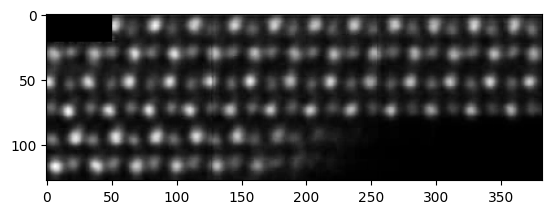

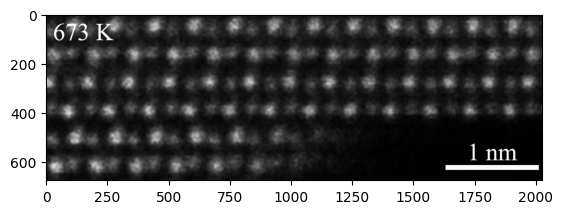

In [12]:
denoise_frame_i = read_frame_i(denoised_video_path,frame_number,mask=[(slice(0, 22), slice(0, 51)),(slice(90, 150), slice(300, 400))])
origin_frame_i = read_frame_i(origin_video_path, frame_number-2)

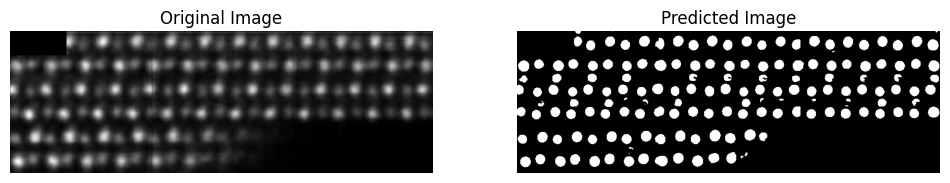

In [13]:
# 示例使用
height_periodicity = 1  # 高度方向的周期数

# 调用预测函数
_, output_image = pred(denoise_frame_i, height_periodicity)

# 可视化原始图像和预测结果
visualize_images(denoise_frame_i, output_image)

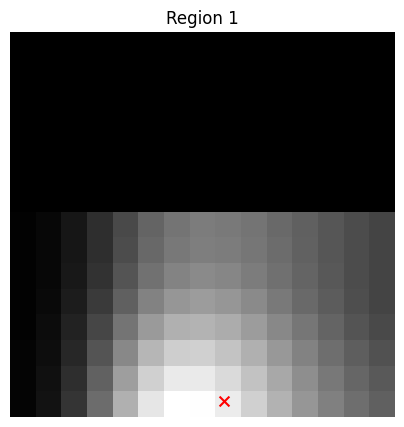

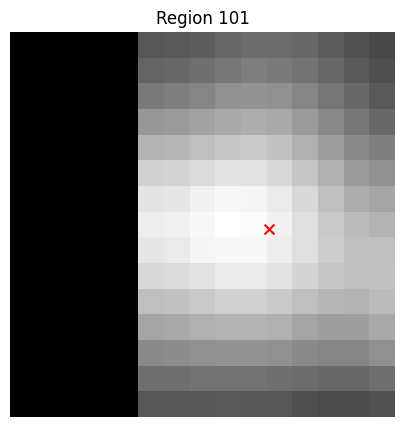

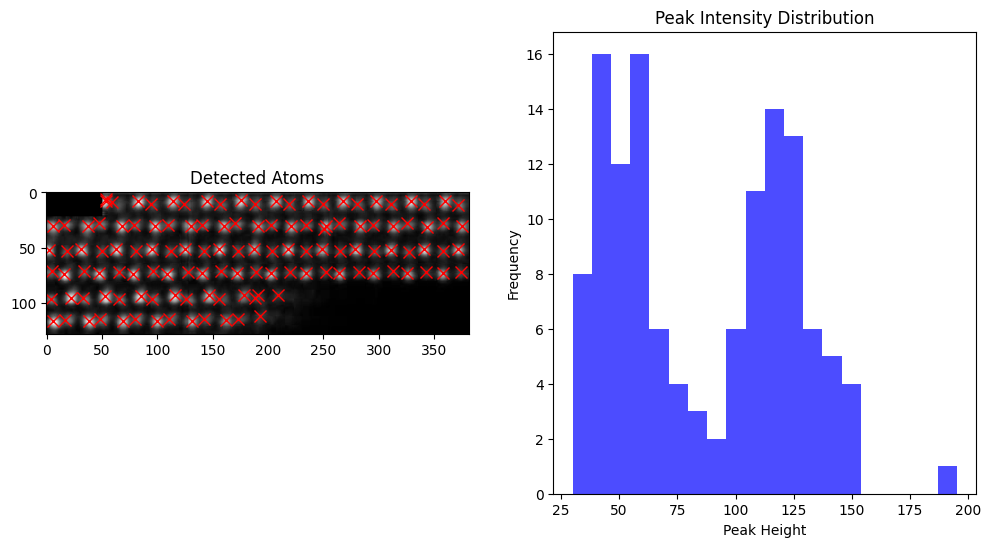

In [14]:
# 处理图像，得到原子位置和峰高
atom_positions = process_images(denoise_frame_i, output_image, blur_kernel=(9, 9), crop_size=15)

# 可视化结果
visualize_results(denoise_frame_i, atom_positions)

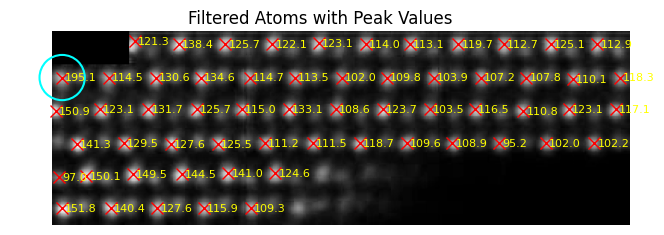

In [19]:
# 示例：对原子位置进行筛选、删除并标注
filtered_atoms = filter_atoms_by_peak(atom_positions, min_peak=95, max_peak=200)
avg_nn_distance = calculate_nearest_neighbor_distances(filtered_atoms)/1.5
final_atoms = remove_close_atoms(filtered_atoms, avg_nn_distance)

# 在图像上标注筛选后的原子
mark_atoms_on_image(denoise_frame_i, final_atoms,avg_nn_distance)

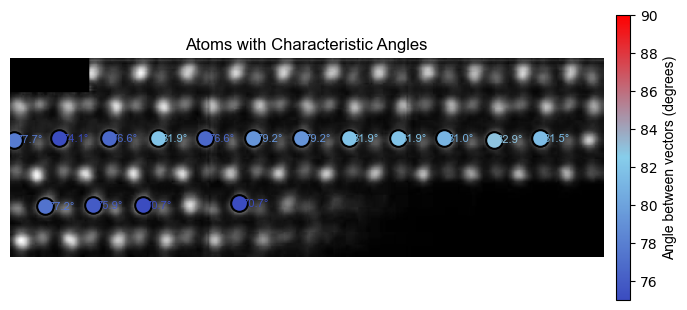

In [32]:
# 提取特征并可视化第一个原子及其邻居
features = extract_features(final_atoms, avg_nn_distance*2.2, plt_feature = 0)
mark_features_on_image(denoise_frame_i, features, plt_text=1, save_path = None)

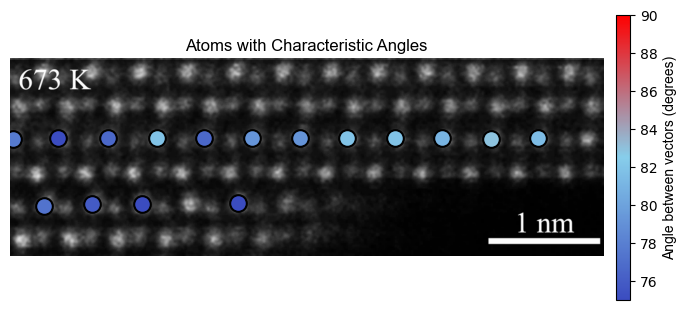

In [33]:


# 示例数据
origin_frame_i = origin_frame_i.resize((1013,338))

factor = origin_frame_i.size[1]/denoise_frame_i.size[1]

# 移除与 target_angles 接近的特征
filtered_features = resize_features(features, factor)
mark_features_on_image(origin_frame_i, filtered_features, plt_text=0, save_path=save_img_path, save_txt_path = save_txt_path)

In [30]:
width, height = origin_frame_i.size


# 1. 根据 y 值划分为两个类别
features_100_400 = [((x, y), peak) for ((x, y), peak) in filtered_features if 50 <= y < 200]
features_400_676 = [((x, y), peak) for ((x, y), peak) in filtered_features if 200 <= y < 338]

# 2. 按 x 值进行排序
features_100_400.sort(key=lambda item: item[0][0])  # 按 x 值排序
features_400_676.sort(key=lambda item: item[0][0])  # 按 x 值排序

# 3. 对于 100:400 范围的类别，在 x=0 和 x=width 处添加端点
if features_100_400:
    x_min_100_400 = 0
    x_max_100_400 = width  # 使用图像宽度作为终点
    features_100_400.insert(0, ((x_min_100_400, features_100_400[0][0][1]), features_100_400[0][1]))  # x=0
    features_100_400.append(((x_max_100_400, features_100_400[-1][0][1]), features_100_400[-1][1]))  # x=width

# 4. 对于 400:676 范围的类别，在 x=0 和 x 最大值+100 处添加端点
if features_400_676:
    x_min_400_676 = 0
    x_max_400_676 = features_400_676[-1][0][0] + 100
    features_400_676.insert(0, ((x_min_400_676, features_400_676[0][0][1]), features_400_676[0][1]))  # x=0
    features_400_676.append(((x_max_400_676, features_400_676[-1][0][1]), features_400_676[-1][1]))  # x 最大值+100


In [438]:
# 创建白色背景的伪彩色图像（原图大小）
pseudo_color_array = np.ones((height, width, 3), dtype=np.uint8) * 255  # 确保背景为白色

# 使用 Coolwarm 颜色条
# 创建自定义的三色颜色条：蓝色-浅黄色-红色
colors = [(0, "#3B4CC0"), (0.5, "skyblue"), (1, "red")]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)
norm = plt.Normalize(vmin=75, vmax=90)

# 使用自定义颜色映射和范围填充伪彩色图像
for y_min, y_max, features in [(50, 200, features_100_400), (200, 338, features_400_676)]:
    for y in range(y_min, y_max):
        for i in range(len(features) - 1):
            x_start = int(features[i][0][0])
            x_end = int(features[i + 1][0][0])
            peak_start = features[i][1]
            peak_end = features[i + 1][1]

            # 确保 x 范围有效
            if x_end > x_start:
                x_range = np.linspace(x_start, x_end, num=(x_end - x_start) + 1)
                
                # 在 x_start 和 x_end 之间进行线性插值，以实现 x 方向的渐变
                for j, x in enumerate(x_range):
                    x = int(x)  # 确保 x 是整数索引

                    # 检查 x 和 y 是否在图像范围内
                    if 0 <= x < width and 0 <= y < height:
                        interp_peak = peak_start + (peak_end - peak_start) * (j / len(x_range))
                        color = cmap(norm(interp_peak))  # 获取对应颜色
                        rgb_color = (np.array(color[:3]) * 255).astype(np.uint8)  # 转换为 RGB 值
                        pseudo_color_array[y, x] = rgb_color  # 将颜色赋值给伪彩色图像


# 将伪彩色图像转换为 PIL 图像并添加黑色边框
pseudo_color_image = Image.fromarray(pseudo_color_array)
border_size = 5
bordered_pseudo_color_image = Image.new("RGB", (width + 2 * border_size, height + 2 * border_size), "black")
bordered_pseudo_color_image.paste(pseudo_color_image, (border_size, border_size))

# 创建一个包含原图和伪彩色图的整体画布，增加 10 像素的间隔
combined_height = height * 2 + 10 + 2 * border_size
combined_image = Image.new("RGB", (width + 2 * border_size, combined_height), "white")
combined_image.paste(origin_frame_i.convert("RGB"), (border_size, 0))
combined_image.paste(bordered_pseudo_color_image, (0, height + 10))

# 绘制颜色条并保存为单独的图片，增加宽度和标签字体大小
fig, ax = plt.subplots(figsize=(1, 3.8))
fig.subplots_adjust(left=0.4, right=0.8, top=0.9, bottom=0.1)
cbar = plt.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=ax, orientation="vertical"
)
# cbar.set_label("Angle", fontsize=24)
cbar.ax.tick_params(labelsize=24)

# 添加自定义标签，确保位置不会与刻度标签重叠
ax.text(2.7,0, "α phase", va='center', ha='left', fontsize=24, transform=ax.transAxes)
ax.text(2.7, (83 - 75.6) / (90 - 75.6), "HT-α phase", va='center', ha='left', fontsize=24, transform=ax.transAxes)
ax.text(2.7,1, "β phase", va='center', ha='left', fontsize=24, transform=ax.transAxes)

plt.savefig("color_bar.png", bbox_inches="tight", pad_inches=0.1, transparent=True)
plt.close()

# 打开 color bar 图片并合并到右边
color_bar_image = Image.open("color_bar.png")
combined_with_colorbar = Image.new("RGB", (width + color_bar_image.width + 2 * border_size, combined_height), "white")
combined_with_colorbar.paste(combined_image, (0, 0))
combined_with_colorbar.paste(color_bar_image, (width + 2 * border_size, height + 10))

# 保存并显示最终图片
combined_with_colorbar.save("combined_result.png")
combined_with_colorbar.show()